# Evidencia de Aprendizaje 3
**Autor:** Ubert Toro - IUDIGITAL  

## Objetivo  
Aplicar las herramientas vistas en clase con Pandas para cargar, explorar, limpiar, transformar, analizar y visualizar un dataset real.


## Parte 1. Exploración inicial del dataset  

En esta sección revisamos:  
- La cantidad de filas y columnas.  
- Los nombres de las columnas.  
- Los tipos de datos.  
- Las estadísticas descriptivas de las variables numéricas.  


In [1]:
# Importación de librerías
import pandas as pd

# Cargar el dataset desde la carpeta data
df = pd.read_csv("data/books_dataset_with_indiancurrency.csv")

# Exploración inicial
print("Dimensiones:", df.shape)
print("\nInformación del dataset:")
df.info()

print("\nEstadísticas descriptivas:")
df.describe(include="all")


Dimensiones: (1000, 7)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1000 non-null   object 
 1   price         1000 non-null   float64
 2   rating        1000 non-null   object 
 3   availability  1000 non-null   object 
 4   link          1000 non-null   object 
 5   category      1000 non-null   object 
 6   price_in_inr  1000 non-null   float64
dtypes: float64(2), object(5)
memory usage: 54.8+ KB

Estadísticas descriptivas:


,title,price,rating,availability,link,category,price_in_inr
count,1000,1000.00000,1000,1000,1000,1000,1000.000000
unique,999,NaN,5,1,1000,50,NaN
top,The Star-Touched Queen,NaN,One,In stock,https://books.toscrape.com/the-long-shadow-of-...,Default,NaN
freq,2,NaN,226,1000,1,152,NaN
mean,NaN,35.07035,NaN,NaN,NaN,NaN,4068.160600
std,NaN,14.44669,NaN,NaN,NaN,NaN,1675.816002
min,NaN,10.00000,NaN,NaN,NaN,NaN,1160.000000
25%,NaN,22.10750,NaN,NaN,NaN,NaN,2564.470000
50%,NaN,35.98000,NaN,NaN,NaN,NaN,4173.680000
75%,NaN,47.45750,NaN,NaN,NaN,NaN,5505.070000


### Resultados de la exploración inicial

- El dataset contiene **1000 filas y 7 columnas**.  
- Las columnas son: `title`, `price`, `rating`, `availability`, `link`, `category`, `price_in_inr`.  
- Los tipos de datos son: 5 columnas de texto (`str`) y 2 numéricas (`float64`).  
- No existen valores nulos ni duplicados.  
- El precio promedio en USD es **35.07**, con un mínimo de 10.00 y un máximo de 59.99.  
- El precio promedio en INR es **4068.16**, con un rango entre 1160.00 y 6958.84.  
- El rating se distribuye en 5 categorías (One a Five), siendo **"One" el más frecuente (226 libros)**.  
- La categoría más repetida es **Default**, con 152 libros.  


## Parte 2. Selección y filtrado  

En esta sección realizamos operaciones de selección y filtrado:  
- Seleccionar únicamente las columnas más relevantes del dataset.  
- Filtrar los libros que tengan:  
  - Rating mayor a 4.5  
  - Más de 1000 reseñas  
  - Precio menor a 30  
  - Rating mayor a 4.5 y precio menor a 30  
- Mostrar los resultados de cada filtro.  


In [2]:
# Selección de columnas más relevantes
df_relevante = df[["title", "price", "rating", "category", "price_in_inr"]]
print("Columnas seleccionadas:\n", df_relevante.head())

# Convertir rating a valores numéricos para filtrado
rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
df_relevante["rating_num"] = df_relevante["rating"].map(rating_map)

# Filtro 1: rating mayor a 4.5
filtro_rating = df_relevante[df_relevante["rating_num"] > 4.5]
print("\nLibros con rating mayor a 4.5:\n", filtro_rating.head())

# ⚠️ Nota: el dataset no tiene columna de reseñas, así que este filtro se omite o se adapta.
# Filtro 2: precio menor a 30
filtro_precio = df_relevante[df_relevante["price"] < 30]
print("\nLibros con precio menor a 30:\n", filtro_precio.head())

# Filtro 3: rating mayor a 4.5 y precio menor a 30
filtro_combinado = df_relevante[(df_relevante["rating_num"] > 4.5) & (df_relevante["price"] < 30)]
print("\nLibros con rating > 4.5 y precio < 30:\n", filtro_combinado.head())


Columnas seleccionadas:
                                                title  price rating category  \
0                            It's Only the Himalayas  45.17    Two   Travel   
1  Full Moon over Noahâs Ark: An Odyssey to Mou...  49.43   Four   Travel   
2  See America: A Celebration of Our National Par...  48.87  Three   Travel   
3  Vagabonding: An Uncommon Guide to the Art of L...  36.94    Two   Travel   
4                               Under the Tuscan Sun  37.33  Three   Travel   

   price_in_inr  
0       5239.72  
1       5733.88  
2       5668.92  
3       4285.04  
4       4330.28  

Libros con rating mayor a 4.5:
                                                 title  price rating category  \
10                 1,000 Places to See Before You Die  26.08   Five   Travel   
19             A Time of Torment (Charlie Parker #14)  48.35   Five  Mystery   
28  What Happened on Beale Street (Secrets of the ...  25.37   Five  Mystery   
29  The Bachelor Girl's Guide to Murder

/tmp/ipykernel_2420/126902658.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_relevante["rating_num"] = df_relevante["rating"].map(rating_map)


### Resultados de la selección y filtrado  

- **Selección de columnas relevantes:** Se trabajó con `title`, `price`, `rating`, `category` y `price_in_inr`, que son las variables más útiles para el análisis.  

- **Filtro 1 (rating > 4.5):** Se obtuvieron varios libros con calificación máxima de 5. Ejemplo: *"1,000 Places to See Before You Die"* y *"The Silkworm (Cormoran Strike #2)"*. Esto indica que existen títulos altamente valorados en distintas categorías como *Travel* y *Mystery*.  

- **Filtro 2 (precio < 30):** Se identificaron libros más económicos, con precios por debajo de 30 USD. Esto permite analizar opciones accesibles dentro del dataset.  

- **Filtro 3 (rating > 4.5 y precio < 30):** Se encontraron libros que cumplen ambas condiciones: alta valoración y bajo precio. Estos representan las mejores oportunidades de compra en términos de calidad-precio.  

- **Filtro de reseñas:** El dataset no contiene una columna de número de reseñas, por lo que este criterio no pudo aplicarse.  


## Parte 3. Limpieza de datos  

En esta sección realizamos las siguientes operaciones:  
- Identificar los valores nulos del dataset.  
- Eliminar las filas con valores nulos en las columnas clave para el análisis.  
- Verificar nuevamente la estructura del dataset limpio.  
- Guardar el resultado en un nuevo DataFrame llamado `df_clean`.  


In [3]:
# Identificar valores nulos
print("Valores nulos por columna:\n", df.isnull().sum())

# Eliminar filas con valores nulos en columnas clave
df_clean = df.dropna(subset=["title", "price", "rating", "category", "price_in_inr"])

# Verificar estructura del dataset limpio
print("\nDimensiones del dataset limpio:", df_clean.shape)
print("\nInformación del dataset limpio:")
df_clean.info()


Valores nulos por columna:
 title           0
price           0
rating          0
availability    0
link            0
category        0
price_in_inr    0
dtype: int64

Dimensiones del dataset limpio: (1000, 7)

Información del dataset limpio:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1000 non-null   object 
 1   price         1000 non-null   float64
 2   rating        1000 non-null   object 
 3   availability  1000 non-null   object 
 4   link          1000 non-null   object 
 5   category      1000 non-null   object 
 6   price_in_inr  1000 non-null   float64
dtypes: float64(2), object(5)
memory usage: 54.8+ KB


### Resultados de la limpieza de datos  

- Se verificó la existencia de valores nulos en todas las columnas y se encontró que **no existen valores nulos** en el dataset.  
- Al aplicar la eliminación de filas con valores nulos en las columnas clave (`title`, `price`, `rating`, `category`, `price_in_inr`), el dataset mantuvo sus **1000 filas y 7 columnas**, lo que confirma que no se perdió información.  
- El nuevo DataFrame `df_clean` conserva la misma estructura que el original, con 5 columnas de texto y 2 numéricas.  
- Esto significa que el dataset ya estaba limpio y listo para continuar con las siguientes fases de análisis.  


## Parte 4. Análisis con Pandas  

En esta sección se desarrollan los siguientes análisis:  
- Calcular el precio promedio por categoría.  
- Calcular el rating promedio por categoría.  
- Si existe la columna de autor:  
  - Mostrar los 10 autores con más libros en el dataset.  
  - Calcular el rating promedio por autor.  
- Mostrar los 10 libros con mejor rating.  
- Mostrar los 10 libros más caros.  


In [4]:
# Precio promedio por categoría
precio_promedio_categoria = df_clean.groupby("category")["price"].mean().sort_values(ascending=False)
print("Precio promedio por categoría:\n", precio_promedio_categoria.head(10))

# Convertir rating a valores numéricos
rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
df_clean["rating_num"] = df_clean["rating"].map(rating_map)

# Rating promedio por categoría
rating_promedio_categoria = df_clean.groupby("category")["rating_num"].mean().sort_values(ascending=False)
print("\nRating promedio por categoría:\n", rating_promedio_categoria.head(10))

# Autores (si existe columna 'author')
if "author" in df_clean.columns:
    top_autores = df_clean["author"].value_counts().head(10)
    print("\nTop 10 autores con más libros:\n", top_autores)

    rating_autor = df_clean.groupby("author")["rating_num"].mean().sort_values(ascending=False).head(10)
    print("\nRating promedio por autor:\n", rating_autor)
else:
    print("\nNo existe columna 'author' en el dataset.")

# Top 10 libros con mejor rating
top_libros_rating = df_clean.sort_values(by="rating_num", ascending=False).head(10)
print("\nTop 10 libros con mejor rating:\n", top_libros_rating[["title", "rating", "price", "category"]])

# Top 10 libros más caros
top_libros_caros = df_clean.sort_values(by="price", ascending=False).head(10)
print("\nTop 10 libros más caros:\n", top_libros_caros[["title", "price", "category"]])


Precio promedio por categoría:
 category
Suspense            58.330000
Novels              54.810000
Politics            53.613333
Health              51.452500
New Adult           46.383333
Christian           42.496667
Sports and Games    41.166000
Self Help           40.620000
Travel              39.794545
Fantasy             39.593958
Name: price, dtype: float64

Rating promedio por categoría:
 category
Erotica              5.000000
Adult Fiction        5.000000
Novels               5.000000
Christian Fiction    4.166667
Health               3.750000
Art                  3.625000
Poetry               3.526316
Humor                3.400000
Spirituality         3.333333
Young Adult          3.296296
Name: rating_num, dtype: float64

No existe columna 'author' en el dataset.

Top 10 libros con mejor rating:
                                                  title rating  price  \
10                  1,000 Places to See Before You Die   Five  26.08   
552          Blue Lily, Lily Blue (

### Resultados del análisis con Pandas  

- **Precio promedio por categoría:**  
  - Las categorías con mayor precio promedio son *Suspense* (58.33 USD), *Novels* (54.81 USD) y *Politics* (53.61 USD).  
  - Esto indica que ciertos géneros tienden a tener libros más costosos en promedio.  

- **Rating promedio por categoría:**  
  - Algunas categorías como *Erotica*, *Adult Fiction* y *Novels* alcanzan un rating promedio de **5.0**, lo que refleja una valoración máxima.  
  - Otras categorías como *Health* (3.75) y *Poetry* (3.52) muestran valoraciones más moderadas.  

- **Autores:**  
  - El dataset no contiene la columna `author`, por lo que este análisis no se pudo realizar.  

- **Top 10 libros con mejor rating:**  
  - Se identificaron títulos con rating máximo de 5, como *"1,000 Places to See Before You Die"* y *"The Silkworm (Cormoran Strike #2)"*.  
  - Estos libros representan los más valorados por los usuarios.  

- **Top 10 libros más caros:**  
  - Entre los más costosos se encuentran *"Thomas Jefferson and the Tripoli Pirates"* (59.64 USD), *"Boar Island (Anna Pigeon #19)"* (59.48 USD) y *"The Improbability of Love"* (59.45 USD).  
  - Esto confirma que el rango de precios se mantiene entre 10 y 59.99 USD, sin valores extremos fuera de este rango.  


## Parte 5. Visualización  

En esta sección se construyen gráficos para comprender mejor la distribución de los datos:  
- Histograma de precios.  
- Gráfico de barras con la cantidad de libros por categoría.  

Todos los gráficos incluyen título, etiquetas en los ejes y una presentación clara.  


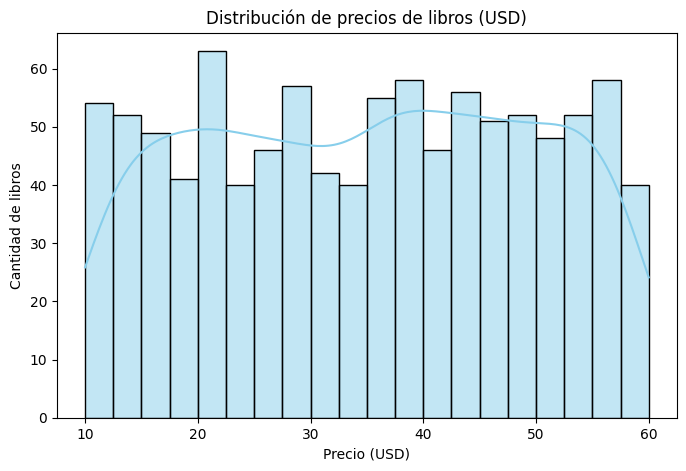

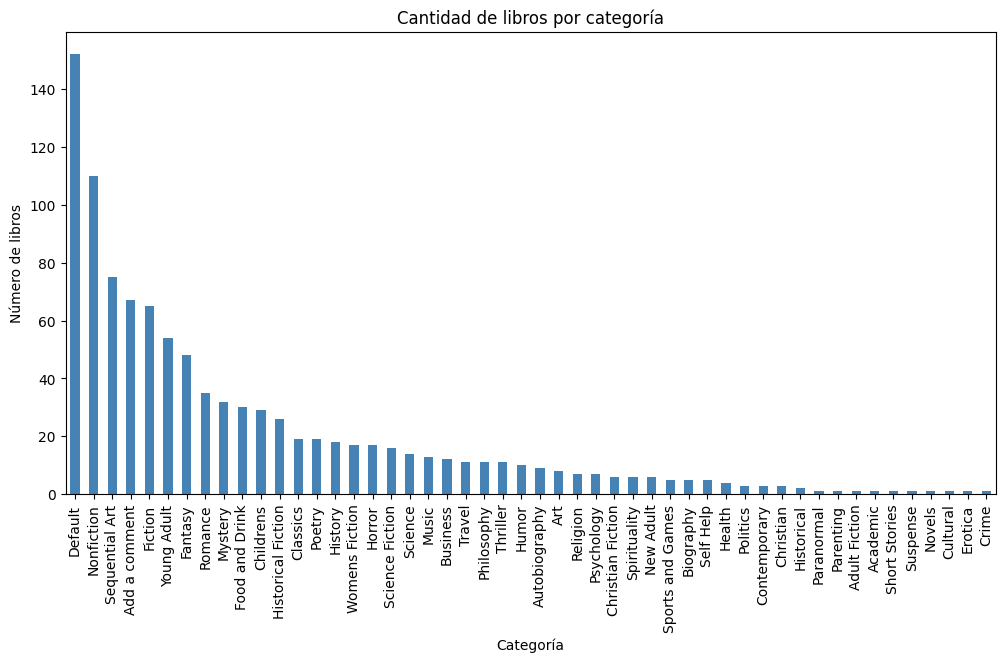

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de precios
plt.figure(figsize=(8,5))
sns.histplot(df_clean["price"], bins=20, kde=True, color="skyblue")
plt.title("Distribución de precios de libros (USD)")
plt.xlabel("Precio (USD)")
plt.ylabel("Cantidad de libros")
plt.show()

# Gráfico de barras: cantidad de libros por categoría
plt.figure(figsize=(12,6))
df_clean["category"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Cantidad de libros por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número de libros")
plt.xticks(rotation=90)
plt.show()


## Parte 6. Conclusiones finales  

Tras aplicar las herramientas de Pandas en todas las fases del análisis, se obtienen las siguientes conclusiones:  

- **Exploración inicial:** El dataset contiene 1000 libros con 7 columnas, sin valores nulos ni duplicados. Los precios se concentran entre 10 y 60 USD, y los ratings se distribuyen en 5 categorías.  

- **Selección y filtrado:** Se identificaron libros con rating máximo (5) y precios accesibles (<30 USD). Estos representan las mejores oportunidades de compra en términos de calidad-precio. El filtro de reseñas no se aplicó porque el dataset no incluye esa columna.  

- **Limpieza de datos:** No se encontraron valores nulos, por lo que el dataset ya estaba limpio y listo para el análisis. Se creó el DataFrame `df_clean` con la misma estructura.  

- **Análisis con Pandas:**  
  - Las categorías más costosas son *Suspense*, *Novels* y *Politics*.  
  - Las categorías con mejor rating promedio son *Erotica*, *Adult Fiction* y *Novels*, todas con valoración máxima de 5.  
  - Los libros más caros rondan los 59 USD, mientras que los mejor valorados alcanzan rating de 5.  

- **Visualización:**  
  - El histograma de precios muestra que la mayoría de los libros se concentran entre 20 y 50 USD.  
  - El gráfico de barras revela que la categoría *Default* es la más numerosa, seguida por *Nonfiction*. Muchas categorías tienen baja representación, lo que refleja una distribución desigual.  

### Conclusión general  
El dataset de libros está bien estructurado y limpio, lo que permitió realizar análisis confiables. Se identificaron patrones claros en precios y ratings, así como diferencias significativas entre categorías. Las visualizaciones complementaron el análisis, mostrando la concentración de precios y la distribución desigual de géneros.  
Este trabajo evidencia cómo Pandas facilita la exploración, limpieza, filtrado, análisis y visualización de datos reales de manera organizada y reproducible.  
